<h1>1. Import libraries</h1>

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
import csv
import os
import tqdm

################## For Data task ##################
from torch.utils.data import DataLoader
from torchvision import transforms
import albumentations as A
from torchvision.transforms import InterpolationMode
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset

################## For training task ##################
import torch
import torchvision
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F

configs = {
    "image_folder": '/kaggle/input/datasets/azurebob2/tumormultitaskdataset/images/',
    "mask_folder": '/kaggle/input/datasets/azurebob2/tumormultitaskdataset/masks/',
    "cls_classes": 4,
    "image_size": 224,
    "n_channels": 3,
    "lr": 1e-03,
    "min_lr": 1e-07,
    "batch_size": 16,
    "num_workers": 2,
    "earlyStopping": 30,
    "max_epoch_num": 50,
    "plateau_patience": 10,

    "project_name": "Multi task learning for Tumor Classification & Segmentation",
    "rs_dir":"/kaggle/working/UnetMultiTask4Cls_Seg",
    "tracking_csv":"/kaggle/working/trainingTracking.csv",
}

os.mkdir(configs["rs_dir"])
configs["tracking_csv"] = os.path.join(configs["rs_dir"],"trainingTracking.csv")
configs["weight_saved_path"] = os.path.join(configs["rs_dir"],"UnetMultiTask4Cls_Seg.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cls_class_names = {0: "noTumor", 1: "meningioma", 2: "glioma", 3: "pituitary"}

<h1>2. Set up baseline for training, validation, testing stage</h1>
<h1>2.1. Loading and Setting up Dataset</h1>

In [2]:
image_paths = []

allTumors = os.listdir(configs["image_folder"])
for i in range(len(allTumors)):
    tumor_img_path = allTumors[i]
    #tumor_mask_path = os.path.join(configs['mask_folder'], allTumors[i].replace(".png", ".npy"))
    image_paths.append(tumor_img_path)


#print(len(image_paths))
#print(len(mask_paths))
divided_dataset_img = {0:[], 1:[], 2:[], 3:[]}
for idx in range(len(image_paths)):
    for k, v in cls_class_names.items():
        if v in image_paths[idx]:
            divided_dataset_img[k].append(image_paths[idx])
            break
trainImagePaths = []
validImagePaths = []
testImagePaths = []
ratio = 0.8
for k, v in cls_class_names.items():
    idx_split = round(ratio * len(divided_dataset_img[k]))
    trainImagePaths.extend(divided_dataset_img[k][:idx_split])

    valid_test_image_paths = divided_dataset_img[k][idx_split:]
    
    idx_split = int(len(valid_test_image_paths) / 2)
 
    validImagePaths.extend(valid_test_image_paths[:idx_split])
    testImagePaths.extend(valid_test_image_paths[idx_split:])
    
print(f"Train images: {len(trainImagePaths)}")
print(f"Valid images: {len(validImagePaths)}")
print(f"Test images: {len(testImagePaths)}")
    

Train images: 3116
Valid images: 389
Test images: 390


<h1>2.2. Create Data loader for Tumor dataset!</h1>
<h1>2.2.1. Check albumentation for 1 image(how it looks like?)</h1>

Tumor Label: meningioma
Image shape: (224, 224, 3)
Mask shape: (224, 224)


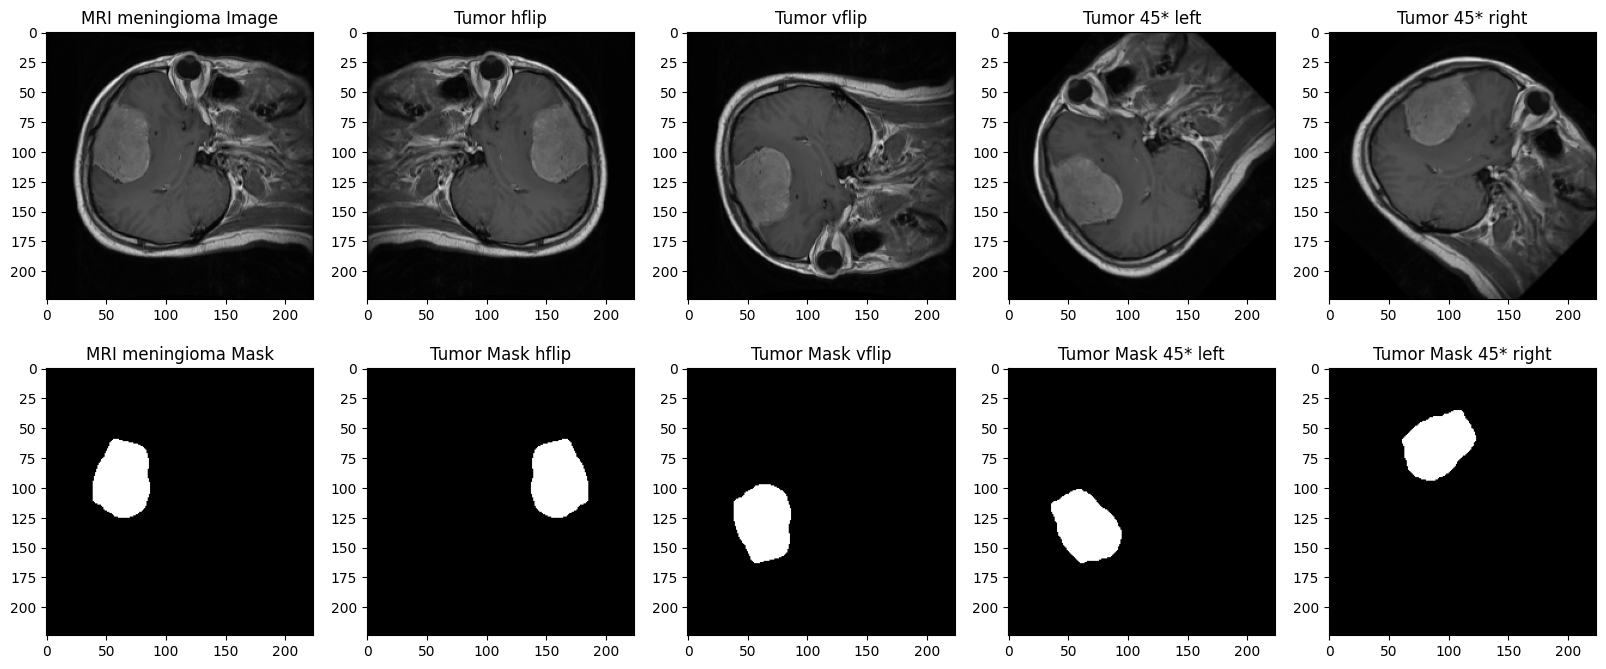

In [3]:
image_path2Show = trainImagePaths[1000]

reverse_class = {v: k for k, v in cls_class_names.items()}

label = image_path2Show.split(".")[0].split("_")[1]

key = reverse_class[label]

print("Tumor Label:", cls_class_names[key])

image2Show = cv2.imread(os.path.join(configs['image_folder'], image_path2Show))[:,:,::-1]
image2Show = cv2.resize(image2Show, (configs["image_size"], configs["image_size"]))
image2Show_hflip = cv2.flip(image2Show, 1)
image2Show_vflip = cv2.flip(image2Show, 0)
(h, w) = image2Show.shape[:2]
center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, 45, 1.0)  # 45° left
image2Show45left = cv2.warpAffine(image2Show, M, (w, h))
M = cv2.getRotationMatrix2D(center, -45, 1.0)  # 45° right
image2Show45right = cv2.warpAffine(image2Show, M, (w, h))

mask2Show = np.load(os.path.join(configs['mask_folder'], image_path2Show.replace(".png", ".npy")))
mask2Show = cv2.resize(mask2Show, (configs["image_size"], configs["image_size"]))
mask2Show_hflip = cv2.flip(mask2Show, 1)
mask2Show_vflip = cv2.flip(mask2Show, 0)

M = cv2.getRotationMatrix2D(center, 45, 1.0)  # 45° left
mask2Show45left = cv2.warpAffine(mask2Show, M, (w, h))
M = cv2.getRotationMatrix2D(center, -45, 1.0)  # 45° right
mask2Show45right = cv2.warpAffine(mask2Show, M, (w, h))

print("Image shape:", image2Show.shape)
print("Mask shape:", mask2Show.shape)
plt.figure(figsize=(20,8))

plt.subplot(2,5,1)
plt.title(f"MRI {label} Image")
plt.imshow(image2Show, cmap='gray')

plt.subplot(2,5,2)
plt.title("Tumor hflip")
plt.imshow(image2Show_hflip, cmap='gray')

plt.subplot(2,5,3)
plt.title("Tumor vflip")
plt.imshow(image2Show_vflip, cmap='gray')

plt.subplot(2,5,4)
plt.title("Tumor 45* left")
plt.imshow(image2Show45left, cmap='gray')

plt.subplot(2,5,5)
plt.title("Tumor 45* right")
plt.imshow(image2Show45right, cmap='gray')

plt.subplot(2,5,6)
plt.title(f"MRI {label} Mask")
plt.imshow(mask2Show, cmap='gray')

plt.subplot(2,5,7)
plt.title("Tumor Mask hflip")
plt.imshow(mask2Show_hflip, cmap='gray')

plt.subplot(2,5,8)
plt.title("Tumor Mask vflip")
plt.imshow(mask2Show_vflip, cmap='gray')

plt.subplot(2,5,9)
plt.title("Tumor Mask 45* left")
plt.imshow(mask2Show45left, cmap='gray')

plt.subplot(2,5,10)
plt.title("Tumor Mask 45* right")
plt.imshow(mask2Show45right, cmap='gray')
plt.show()

<h1>2.2.2. Setting up dataloader format for all images</h1>

In [28]:
dataset_mean = [0.15717137, 0.15716884, 0.1571717]
dataset_std  = [0.17174117, 0.17173925, 0.17174085]

train_tf = A.Compose(
    [
        A.Resize(configs["image_size"], configs["image_size"]),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=360, border_mode=0, p=0.5),
        A.Normalize(mean=dataset_mean, std=dataset_std),
        ToTensorV2()
    ],
    additional_targets={'mask': 'mask'}
)

val_tf = A.Compose(
    [
        A.Resize(configs["image_size"], configs["image_size"]),
        A.Normalize(mean=dataset_mean, std=dataset_std),
        ToTensorV2()
    ],
    additional_targets={'mask': 'mask'}
)

test_tf = A.Compose(
    [
        A.Resize(configs["image_size"], configs["image_size"]),
        A.Normalize(mean=dataset_mean, std=dataset_std),
        ToTensorV2()
    ],
)

In [5]:
class TumorDataset(Dataset):
    def __init__(self, configs, images, transform):
        self.images = images
        self.transform = transform
        self.configs = configs

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        #print(img_path)
        reverse_class = {v: k for k, v in cls_class_names.items()}
        label = img_path.split(".")[0].split("_")[1]
        label = reverse_class[label]

        image = cv2.imread(os.path.join(self.configs['image_folder'], img_path))[:,:,::-1]
        mask = np.load(os.path.join(self.configs['mask_folder'], img_path.replace(".png", ".npy")))
        # print(f"ehhh: {mask.shape}")

        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # print(image.shape)
        # print(mask.shape)
        # print(label)
        # print("--------------")
        mask = mask.unsqueeze(0)
        return image, mask, label

In [6]:
train_data = TumorDataset(configs, trainImagePaths, transform=train_tf)
val_data   = TumorDataset(configs, validImagePaths, transform=val_tf)

train_loader = DataLoader(train_data, batch_size=20, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=20, shuffle=True)

<h1>2.3. Exploring Data</h1>

In [7]:
imagenet_mean_tensor  = torch.tensor([0.15717137, 0.15716884, 0.1571717]).view(3,1,1)
imagenet_std_tensor    = torch.tensor([0.17174117, 0.17173925, 0.17174085]).view(3,1,1)
#imagenet_mean_tensor  = torch.tensor([1, 1, 1]).view(3,1,1)
#imagenet_std_tensor    = torch.tensor([0, 0, 0]).view(3,1,1)
def denormalize(tensor):
    return (tensor * imagenet_std_tensor + imagenet_mean_tensor).clamp(0, 1)

<h1>2.3.1 Training images in train</h1>

torch.Size([20, 3, 224, 224])
torch.Size([20, 1, 224, 224])
Images min: -0.9151678085327148
Images max: 4.816283226013184
Masks min: 0
Masks max: 1
ready


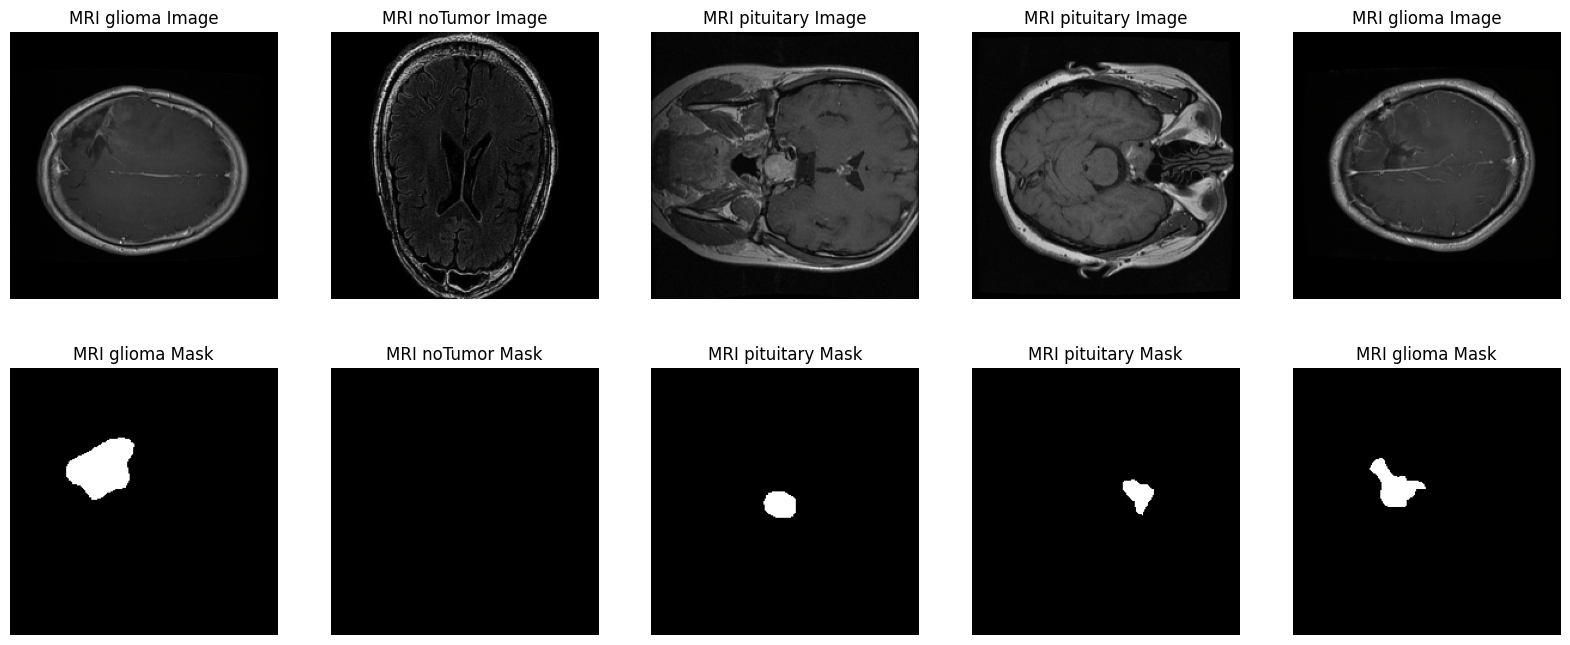

In [8]:
images, masks, labels = next(iter(train_loader))
print(images.shape)  # (batch_size, 3, 224, 224)
print(masks.shape)   # (batch_size, 1, 224, 224)

images_to_show = images[:20]
masks_to_show = masks[:20]
labels_to_show = labels[:20]
print("Images min:", images_to_show.min().item())
print("Images max:", images_to_show.max().item())

print("Masks min:", masks_to_show.min().item())
print("Masks max:", masks_to_show.max().item())
print("ready")


plt.figure(figsize=(20,8))

for i in range(5):
    # Image
    plt.subplot(2,5,i+1)
    plt.title(f"MRI {cls_class_names[labels[i].item()]} Image")
    showImg = denormalize(images_to_show[i]).permute(1,2,0).numpy()
    plt.imshow(showImg)
    plt.axis('off')

    # Mask
    plt.subplot(2,5,i+6)
    plt.title(f"MRI {cls_class_names[labels[i].item()]} Mask")
    showMask = masks_to_show[i].permute(1,2,0).numpy()
    plt.imshow(showMask, cmap='gray')
    plt.axis('off')

plt.show()

<h1>2.3.2 val images in val</h1>

torch.Size([20, 3, 224, 224])
torch.Size([20, 1, 224, 224])
Images min: -0.9151678085327148
Images max: 4.907620906829834
Masks min: 0
Masks max: 1
ready


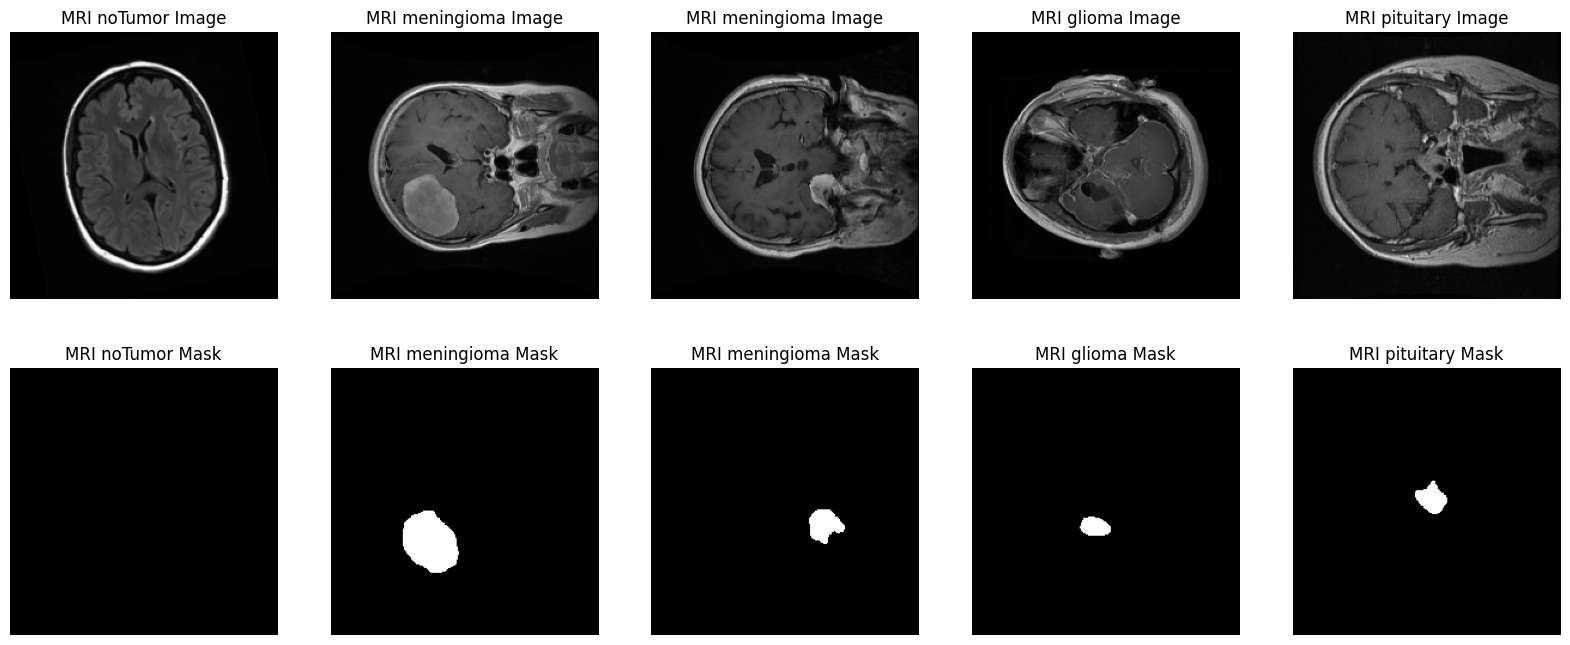

In [9]:
images, masks, labels = next(iter(val_loader))
print(images.shape)  # (batch_size, 3, 224, 224)
print(masks.shape)   # (batch_size, 1, 224, 224)

images_to_show = images[:20]
masks_to_show = masks[:20]
labels_to_show = labels[:20]
print("Images min:", images_to_show.min().item())
print("Images max:", images_to_show.max().item())

print("Masks min:", masks_to_show.min().item())
print("Masks max:", masks_to_show.max().item())
print("ready")

plt.figure(figsize=(20,8))

for i in range(5):
    # Image
    plt.subplot(2,5,i+1)
    plt.title(f"MRI {cls_class_names[labels[i].item()]} Image")
    showImg = denormalize(images_to_show[i]).permute(1,2,0).numpy()
    plt.imshow(showImg)
    plt.axis('off')

    # Mask
    plt.subplot(2,5,i+6)
    plt.title(f"MRI {cls_class_names[labels[i].item()]} Mask")
    showMask = masks_to_show[i].permute(1,2,0).numpy()
    plt.imshow(showMask, cmap='gray')
    plt.axis('off')

plt.show()

<h1>3.Loading and Setup model</h1>
<h1>3.1 Unet Components</h1>

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)
    
    
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DownBlock, self).__init__()
        self.double_conv = DoubleConv(in_channels, out_channels)
        self.down_sample = nn.MaxPool2d(2)

    def forward(self, x):
        skip_out   = self.double_conv(x)
        down_out = self.down_sample(skip_out)
        return (down_out, skip_out)

class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up_sample = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
        self.double_conv = DoubleConv(in_channels//2 + skip_channels, out_channels)

    def forward(self, down_input, skip_input):
        #print(down_input.shape) 
        #print(skip_input.shape)
        x = self.up_sample(down_input)
        #print(x.shape)
        if x.shape[2:] != skip_input.shape[2:]:
            x = F.interpolate(x, size=skip_input.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip_input], dim=1)
        #print(x.shape)
        return self.double_conv(x)
        
# class UpBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super(UpBlock, self).__init__()

#         self.up_sample = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)        
#         self.double_conv = DoubleConv(in_channels, out_channels)

#     def forward(self, down_input , skip_input):
#         print(down_input.shape) #torch.Size([32, 1024, 14, 14])
#         print(skip_input.shape)
#         x = self.up_sample(down_input)
#         print(x.shape)
#         x = torch.cat([x, skip_input], dim=1)
#         return self.double_conv(x)

# torch.Size([32, 1024, 14, 14])
# torch.Size([32, 512, 56, 56])
# torch.Size([32, 512, 28, 28])

In [11]:
class UNet(nn.Module):
    def __init__(self, n_channels = 3, cls_classes = 4):
        super(UNet, self).__init__()
        self.n_channels = n_channels

        self.inc = (DoubleConv(n_channels, 64))
        #Down Sampling
        self.down1 = (DownBlock(64, 128))
        self.down2 = (DownBlock(128, 256))
        self.down3 = (DownBlock(256, 512))
        self.down4 = (DownBlock(512, 1024))

        # classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, cls_classes)
        )
        
        #Up Sampling
        # self.up1 = (UpBlock(1024, 512))
        # self.up2 = (UpBlock(512, 256))
        # self.up3 = (UpBlock(256, 128))
        # self.up4 = (UpBlock(128, 64))
        self.up1 = UpBlock(1024, 512, 512)
        self.up2 = UpBlock(512, 256, 256)
        self.up3 = UpBlock(256, 128, 128)
        self.up4 = UpBlock(128, 64, 64)
        #Sengmentation head
        self.outc = nn.Conv2d(64, 1, kernel_size=1) # 1 for binary class

    def forward(self, x):
        # print(x.shape)
        x1 = self.inc(x)
        # print(f"x1.shape: {x1.shape}")
        # # Down Sampling
        x2, skip2 = self.down1(x1)
        #print(f"x2.shape: {x2.shape}, skip2.shape: {skip2.shape}")
        x3, skip3 = self.down2(x2)
        #print(f"x3.shape: {x3.shape}, skip3.shape: {skip3.shape}")
        x4, skip4 = self.down3(x3)
        #print(f"x4.shape: {x4.shape}, skip4.shape: {skip4.shape}")
        x5, _ = self.down4(x4)
        #print(f"x5.shape: {x5.shape}, skip5.shape: {_.shape}")
    
        # Classification Output
        #print(x5.shape)
        cls_out = self.classifier(x5)
    
        # Up Sampling
        x = self.up1(x5, skip4)
        x = self.up2(x, skip3)
        x = self.up3(x, skip2)
        x = self.up4(x, x1)
    
        # Segmentation Output
        seg_out = self.outc(x)
    
        return seg_out, cls_out

In [12]:
# Input      : [B, 3, 224,224]

# Encoder
# x1         : [B, 64,224,224]
# x2         : [B,128,112,112]
# x3         : [B,256,56,56]
# x4         : [B,512,28,28]
# x5         : [B,1024,14,14]

# Decoder
# up1        : [B,512,28,28]
# up2        : [B,256,56,56]
# up3        : [B,128,112,112]
# up4        : [B,64,224,224]

# Output     : [B,1,224,224]
model = UNet(n_channels = configs['n_channels'], cls_classes = configs['cls_classes'])

<h1>4. Setup training process</h1>
<h1>4.1. Setup DiceLoss for segmentation part</h1>

In [13]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        """
        Args:
            logits: raw output from the model, shape (B, 1, H, W)
            targets: ground truth masks, shape (B, 1, H, W), values 0 or 1
        """
        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(logits)
        
        # Flatten
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)
        
        # Compute Dice coefficient
        intersection = (probs_flat * targets_flat).sum(dim=1)
        union = probs_flat.sum(dim=1) + targets_flat.sum(dim=1)
        
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        
        # Dice loss = 1 - Dice coefficient
        loss = 1 - dice
        return loss.mean()  # average over batch

<h1>4.2. training flow</h1>

In [14]:
class UNet_Multitask_Trainer:
    def __init__(self, configs, model, device, seg_weight=0.5):
        self.device = device
        self.model = model.to(device)
        
        self.cls_loss_fn = nn.CrossEntropyLoss()
        self.seg_loss_fn =  DiceLoss()
        self.seg_weight = seg_weight

        self.optimizer = torch.optim.RAdam(params = model.parameters(), lr=configs['lr'])
        self.lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer = self.optimizer, T_max=configs['max_epoch_num'])

        # storage for metrics
        self.train_metrics = []
        self.val_metrics = []
        self.lrTracking = []
        self.best_val_score = 0.0   # 0.5 * classification accuracy + 0.5 * IOU

        #Creating Tracking
        header = ["epoch", "train_total_loss", "train_cls_loss", "train_cls_acc", "train_seg_loss", "train_seg_dice", 
        "train_seg_iou", "train_seg_pixel_acc", "val_total_loss", "val_cls_loss", "val_cls_acc", "val_seg_loss", 
        "val_seg_dice", "val_seg_iou", "val_seg_pixel_acc", "best_val_score","learning_rate", "train_combined_accuracy", "val_combined_accuracy"]
    
        with open(configs["tracking_csv"], mode="w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(header)
        print("Tracking CSV is created!")
        
    # --- segmentation metrics ---
    def pixel_accuracy(self, pred, target):
        pred = (torch.sigmoid(pred) > 0.5).float()
        correct = (pred == target).float().sum()
        total = target.numel()
        return (correct / total).item()

    def dice_score(self, pred, target, eps=1e-6):
        pred = (torch.sigmoid(pred) > 0.5).float()
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()
        return ((2*intersection + eps) / (union + eps)).item()

    def iou_score(self, pred, target, eps=1e-6):
        pred = (torch.sigmoid(pred) > 0.5).float()
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum() - intersection
        return ((intersection + eps) / (union + eps)).item()

    # --- training loop ---
    def train_one_epoch(self, train_loader, step_loop):
        self.model.train()

        metrics = {
            "cls_loss": 0.0, "cls_acc": 0.0,
            "seg_loss": 0.0, "seg_pixel_acc": 0.0, "seg_dice": 0.0, "seg_iou": 0.0,
            "total_loss": 0.0
        }
        total_examples = 0

        for images, masks, labels in tqdm.tqdm(train_loader, desc=f"Epoch {step_loop}", colour="blue"):

            images = images.to(self.device)
            masks = masks.to(self.device)
            labels = labels.to(self.device)

            self.optimizer.zero_grad()
            seg_out, cls_out = self.model(images)

            cls_loss = self.cls_loss_fn(cls_out, labels)
            seg_loss = self.seg_loss_fn(seg_out, masks)
            loss = (1- self.seg_weight) * cls_loss + self.seg_weight * seg_loss

            loss.backward()
            self.optimizer.step()

            batch_size = labels.size(0)
            total_examples += batch_size

            # classification
            metrics["cls_loss"] += cls_loss.item() * batch_size
            metrics["cls_acc"] += (cls_out.argmax(dim=1) == labels).sum().item()

            # segmentation
            metrics["seg_loss"] += seg_loss.item() * batch_size
            metrics["seg_pixel_acc"] += self.pixel_accuracy(seg_out, masks) * batch_size
            metrics["seg_dice"] += self.dice_score(seg_out, masks) * batch_size
            metrics["seg_iou"] += self.iou_score(seg_out, masks) * batch_size

            # total loss
            metrics["total_loss"] += loss.item() * batch_size

        # normalize
        for k in metrics:
            metrics[k] /= total_examples

        self.train_metrics.append(metrics)
        return metrics

    # --- evaluation loop ---
    def evaluate(self, val_loader, step_loop):
        self.model.eval()
        metrics = {
            "cls_loss": 0.0, "cls_acc": 0.0,
            "seg_loss": 0.0, "seg_pixel_acc": 0.0, "seg_dice": 0.0, "seg_iou": 0.0,
            "total_loss": 0.0
        }
        total_examples = 0

        with torch.no_grad():
            for images, masks, labels in tqdm.tqdm(val_loader, desc=f"Val {step_loop}", colour="green"):

                images = images.to(self.device)
                masks = masks.to(self.device)
                labels = labels.to(self.device)

                seg_out, cls_out = self.model(images)

                cls_loss = self.cls_loss_fn(cls_out, labels)
                seg_loss = self.seg_loss_fn(seg_out, masks)
                loss = (1- self.seg_weight) * cls_loss + self.seg_weight * seg_loss

                batch_size = labels.size(0)
                total_examples += batch_size

                # classification
                metrics["cls_loss"] += cls_loss.item() * batch_size
                metrics["cls_acc"] += (cls_out.argmax(dim=1) == labels).sum().item()

                # segmentation
                metrics["seg_loss"] += seg_loss.item() * batch_size
                metrics["seg_pixel_acc"] += self.pixel_accuracy(seg_out, masks) * batch_size
                metrics["seg_dice"] += self.dice_score(seg_out, masks) * batch_size
                metrics["seg_iou"] += self.iou_score(seg_out, masks) * batch_size

                metrics["total_loss"] += loss.item() * batch_size

        for k in metrics:
            metrics[k] /= total_examples

        self.val_metrics.append(metrics)
        return metrics

    # --- run all epochs ---
    def run(self, epochs, train_loader, val_loader):
        for epoch in range(1, epochs + 1):
            train_metrics = self.train_one_epoch(train_loader, epoch)
            val_metrics = self.evaluate(val_loader, epoch)
    
            self.lr_scheduler.step()
            current_lr = self.optimizer.param_groups[0]["lr"]
            self.lrTracking.append(current_lr)
    
            print(f"Epoch {epoch:02d}")
            print(f"Train: loss={train_metrics['total_loss']:.4f}, cls_acc={train_metrics['cls_acc']*100:.2f}%, "
                  f"seg_dice={train_metrics['seg_dice']:.4f}, seg_iou={train_metrics['seg_iou']:.4f}")
            print(f"Val  : loss={val_metrics['total_loss']:.4f}, cls_acc={val_metrics['cls_acc']*100:.2f}%, "
                  f"seg_dice={val_metrics['seg_dice']:.4f}, seg_iou={val_metrics['seg_iou']:.4f}")
            print(f"learning rate: {current_lr}")
    
            # --- compute combined score ---
            combined_train_score = 0.5 * train_metrics['cls_acc'] + 0.5 * train_metrics['seg_iou']
            combined_val_score = 0.5 * val_metrics['cls_acc'] + 0.5 * val_metrics['seg_iou']

            # --- save only if improved ---
            if combined_val_score > self.best_val_score:
                self.best_val_score = combined_val_score
                print(f"Saved new best model at epoch {epoch}")
    
                state = {"net": self.model.state_dict(),
                         "best_val_score": self.best_val_score,
                         "train_metrics": self.train_metrics,
                         "val_metrics": self.val_metrics,
                         "optimizer": self.optimizer.state_dict(),}#
                torch.save(state, configs['weight_saved_path'])
                
            # --- append metrics to CSV ---
            row = [epoch, train_metrics['total_loss'], train_metrics['cls_loss'], train_metrics['cls_acc'], train_metrics['seg_loss'], 
                   train_metrics['seg_dice'], train_metrics['seg_iou'], train_metrics['seg_pixel_acc'], val_metrics['total_loss'], 
                   val_metrics['cls_loss'], val_metrics['cls_acc'], val_metrics['seg_loss'], val_metrics['seg_dice'], val_metrics['seg_iou'], 
                   val_metrics['seg_pixel_acc'], self.best_val_score, current_lr, combined_train_score, combined_val_score]
    
            with open(configs["tracking_csv"], mode="a", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(row)

<h1>5. Start Training and Evaluating</h1>

In [15]:
train_loader = DataLoader(train_data, batch_size = configs["batch_size"], num_workers=configs["num_workers"], shuffle=True)
val_loader = DataLoader(val_data , batch_size = configs["batch_size"], num_workers=configs["num_workers"], shuffle=False)

In [16]:
trainer = UNet_Multitask_Trainer(
    model=model,
    device=device,
    configs=configs,
)

trainer.run(
    epochs=configs['max_epoch_num'],
    train_loader=train_loader,
    val_loader=val_loader
)

Tracking CSV is created!


Val 1: 100%|██████████| 25/25 [00:08<00:00,  3.10it/s]


Epoch 01
Train: loss=0.8930, cls_acc=65.98%, seg_dice=0.0795, seg_iou=0.0416
Val  : loss=4.4295, cls_acc=32.65%, seg_dice=0.1316, seg_iou=0.0726
learning rate: 0.0009990133642141358
Saved new best model at epoch 1


Val 2: 100%|██████████| 25/25 [00:07<00:00,  3.21it/s]


Epoch 02
Train: loss=0.8141, cls_acc=70.99%, seg_dice=0.1106, seg_iou=0.0590
Val  : loss=5.6381, cls_acc=22.11%, seg_dice=0.0730, seg_iou=0.0386
learning rate: 0.000996057350657239


...

Epoch 10
Train: loss=0.5166, cls_acc=83.99%, seg_dice=0.3679, seg_iou=0.2305
Val  : loss=0.6104, cls_acc=78.66%, seg_dice=0.3686, seg_iou=0.2566
learning rate: 0.0009045084971874736


Val 11: 100%|██████████| 25/25 [00:08<00:00,  3.11it/s]


Epoch 11
Train: loss=0.4986, cls_acc=85.43%, seg_dice=0.3815, seg_iou=0.2412
Val  : loss=0.5283, cls_acc=84.83%, seg_dice=0.3881, seg_iou=0.2743
learning rate: 0.0008852566213878945
Saved new best model at epoch 11


Epoch 12:   1%|          | 2/195 [00:02<04:38,  1.44s/it]


KeyboardInterrupt: 

<h1>5.1 Result</h1>
<h1>5.2 LineCharts</h1>

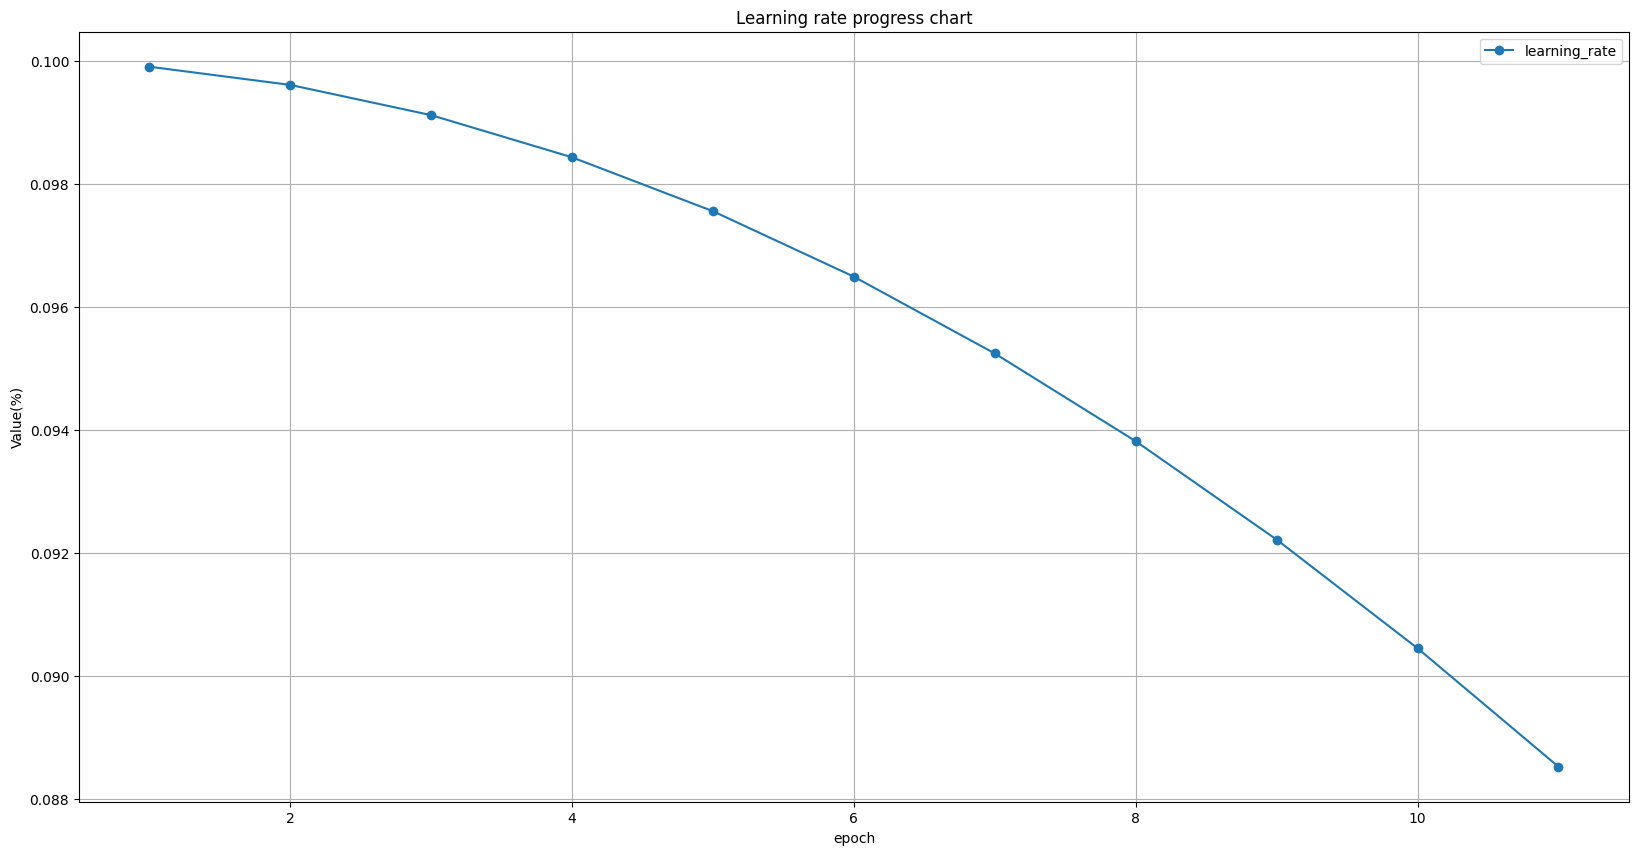

In [17]:
import pandas as pd
df = pd.read_csv(configs['tracking_csv'])
plt.figure(figsize=(20, 10)) 
x = (df['epoch']).tolist()

# Create the line chart
plt.plot(x, df["learning_rate"] * 100, marker='o', label='learning_rate')

# Add labels and title
plt.xlabel("epoch")
plt.ylabel("Value(%)")
plt.title("Learning rate progress chart")
plt.legend()
ticks = list(x[::10])
if x[-1] not in ticks:
    ticks.append(x[-1])
plt.grid(True)

plt.show()

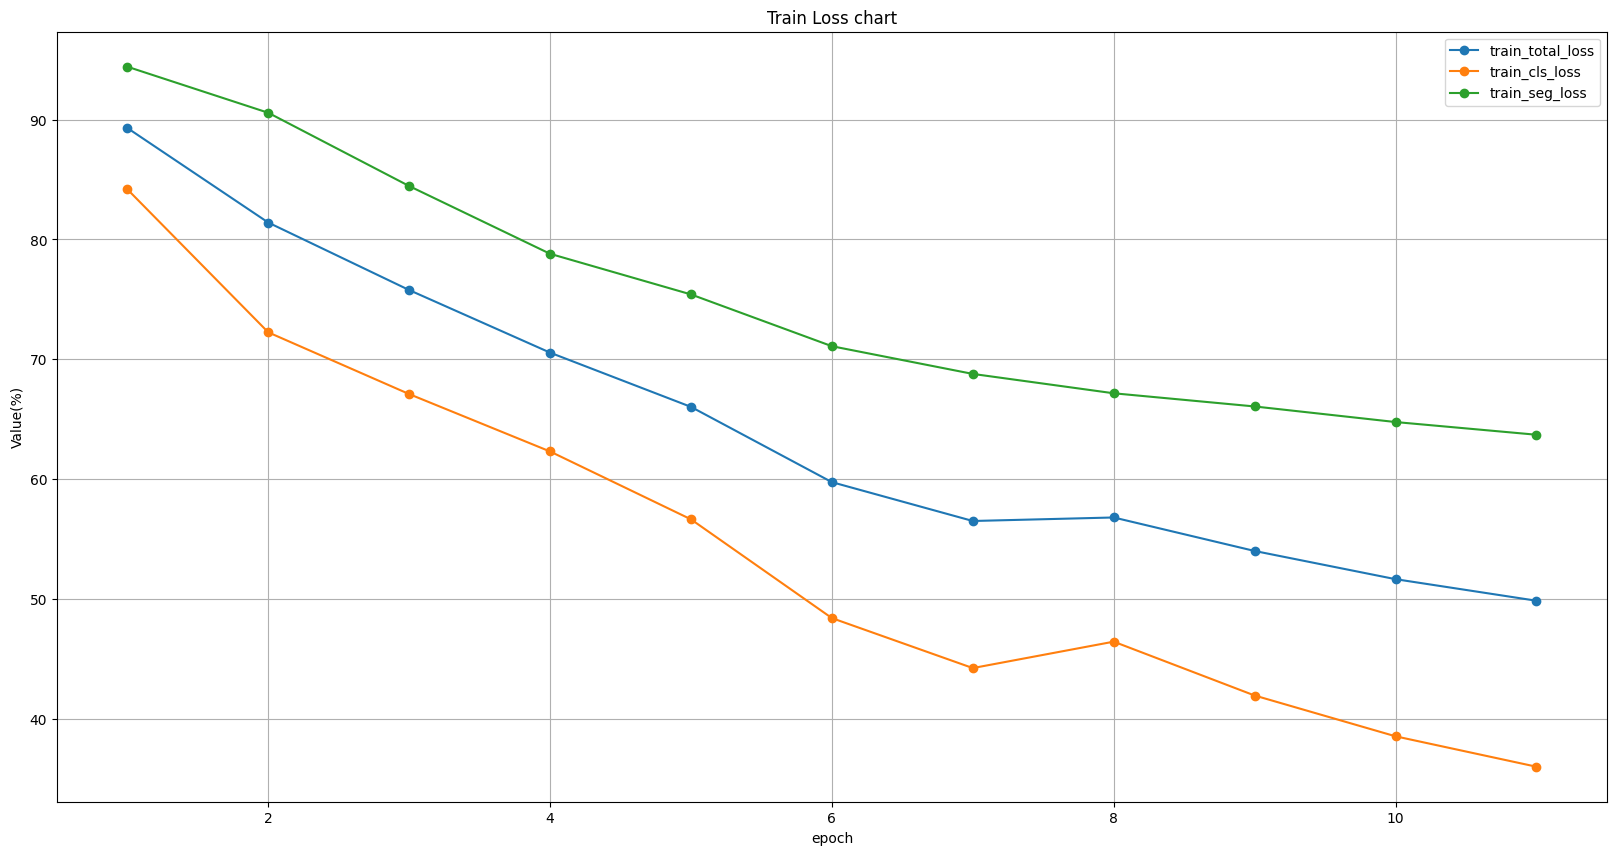

In [18]:
import pandas as pd
df = pd.read_csv(configs['tracking_csv'])
plt.figure(figsize=(20, 10)) 
x = (df['epoch']).tolist()

# Create the line chart
plt.plot(x, df["train_total_loss"] * 100, marker='o', label='train_total_loss')
plt.plot(x, df["train_cls_loss"] * 100, marker='o', label='train_cls_loss')
plt.plot(x, df["train_seg_loss"] * 100, marker='o', label='train_seg_loss')

# Add labels and title
plt.xlabel("epoch")
plt.ylabel("Value(%)")
plt.title("Train Loss chart")
plt.legend()
ticks = list(x[::10])
if x[-1] not in ticks:
    ticks.append(x[-1])
plt.grid(True)

plt.show()

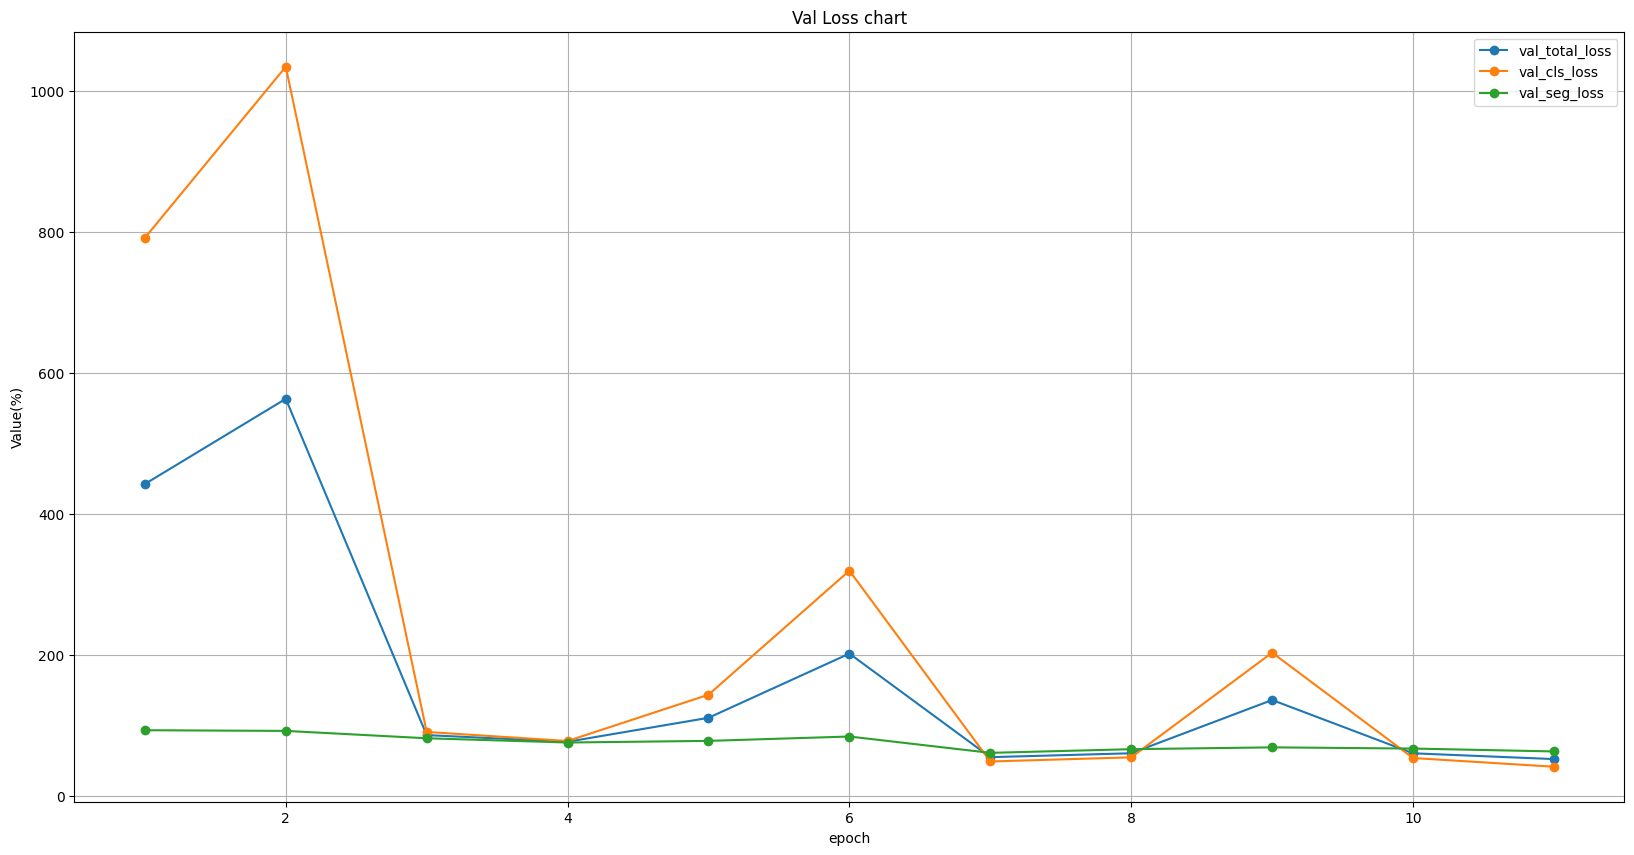

In [20]:
import pandas as pd
df = pd.read_csv(configs['tracking_csv'])
plt.figure(figsize=(20, 10)) 
x = (df['epoch']).tolist()

# Create the line chart
plt.plot(x, df["val_total_loss"] * 100, marker='o', label='val_total_loss')
plt.plot(x, df["val_cls_loss"] * 100, marker='o', label='val_cls_loss')
plt.plot(x, df["val_seg_loss"] * 100, marker='o', label='val_seg_loss')

# Add labels and title
plt.xlabel("epoch")
plt.ylabel("Value(%)")
plt.title("Val Loss chart")
plt.legend()
ticks = list(x[::10])
if x[-1] not in ticks:
    ticks.append(x[-1])
plt.grid(True)

plt.show()

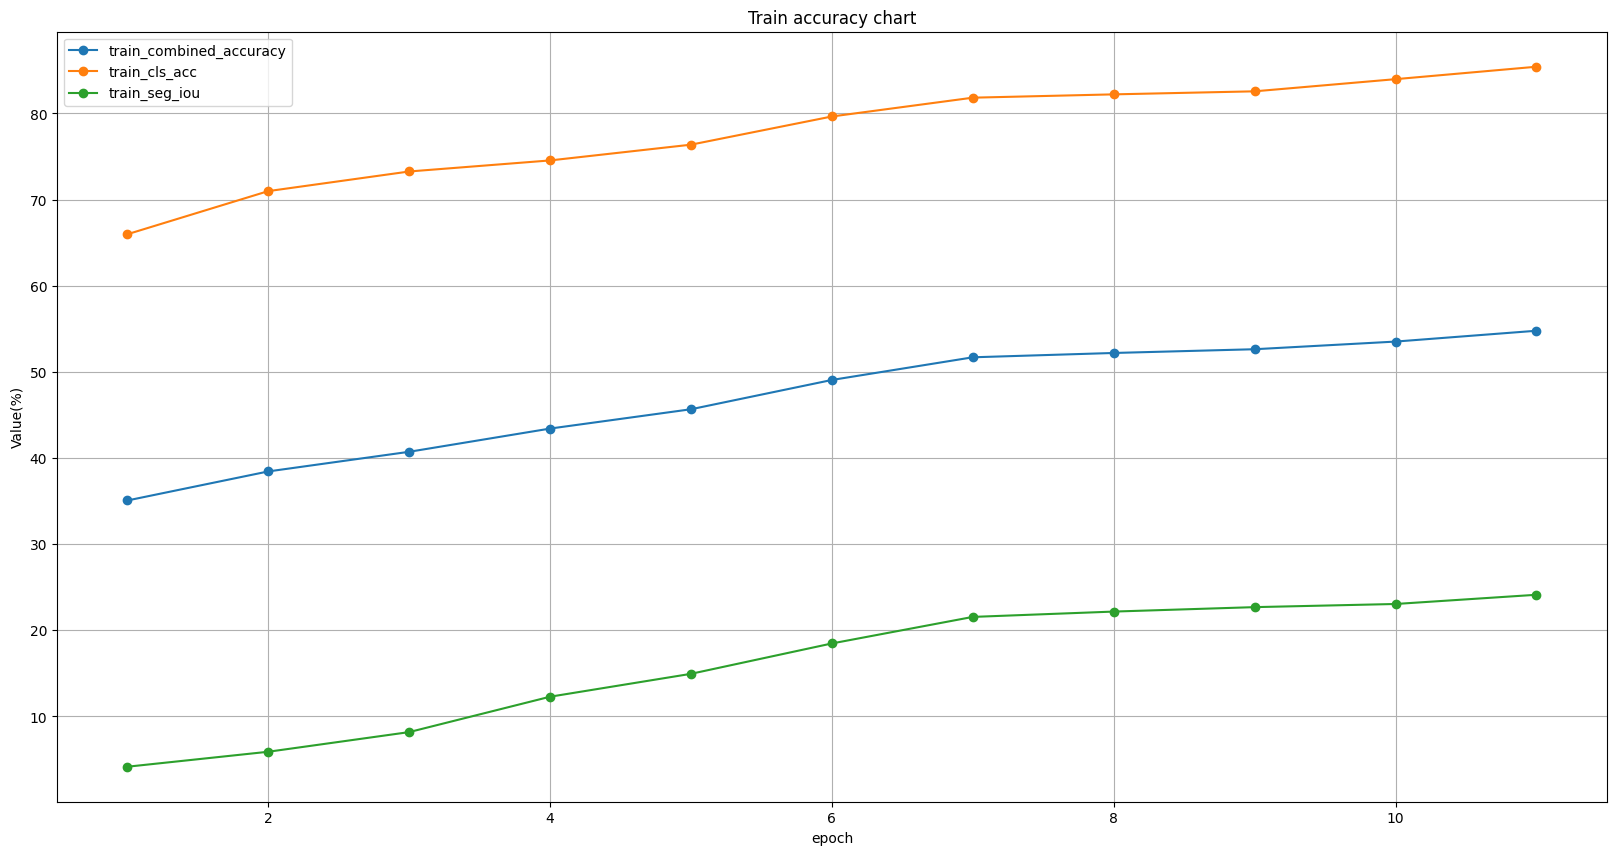

In [21]:
import pandas as pd
df = pd.read_csv(configs['tracking_csv'])
plt.figure(figsize=(20, 10)) 
x = (df['epoch']).tolist()

# Create the line chart
plt.plot(x, df["train_combined_accuracy"] * 100, marker='o', label='train_combined_accuracy')
plt.plot(x, df["train_cls_acc"] * 100, marker='o', label='train_cls_acc')
plt.plot(x, df["train_seg_iou"] * 100, marker='o', label='train_seg_iou')

# Add labels and title
plt.xlabel("epoch")
plt.ylabel("Value(%)")
plt.title("Train accuracy chart")
plt.legend()
ticks = list(x[::10])
if x[-1] not in ticks:
    ticks.append(x[-1])
plt.grid(True)

plt.show()

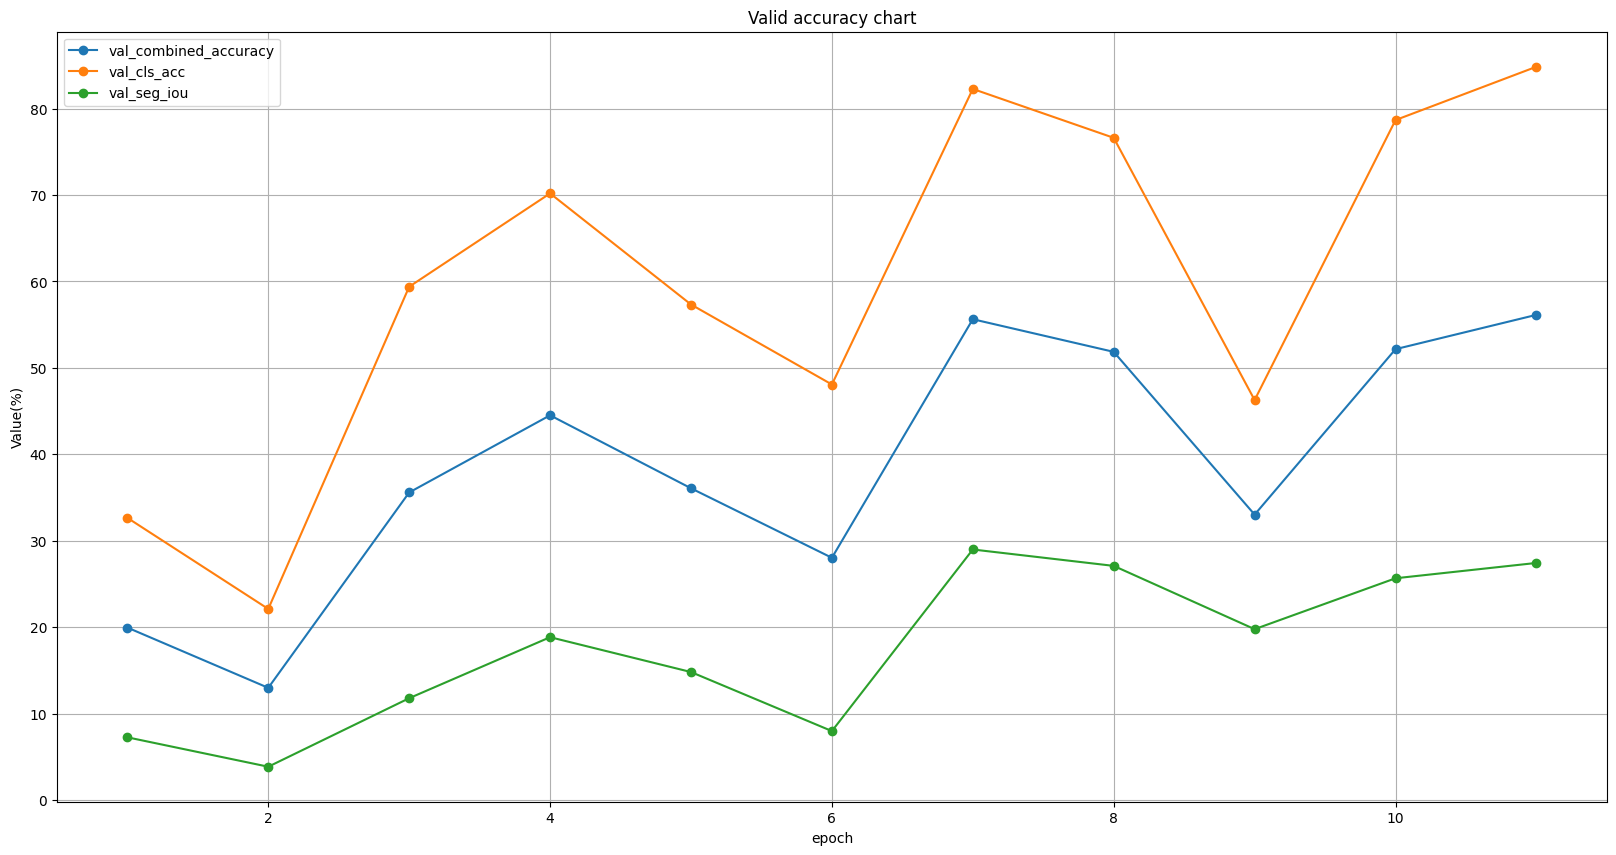

In [22]:
import pandas as pd
df = pd.read_csv(configs['tracking_csv'])
plt.figure(figsize=(20, 10)) 
x = (df['epoch']).tolist()

# Create the line chart
plt.plot(x, df["val_combined_accuracy"] * 100, marker='o', label='val_combined_accuracy')
plt.plot(x, df["val_cls_acc"] * 100, marker='o', label='val_cls_acc')
plt.plot(x, df["val_seg_iou"] * 100, marker='o', label='val_seg_iou')

# Add labels and title
plt.xlabel("epoch")
plt.ylabel("Value(%)")
plt.title("Valid accuracy chart")
plt.legend()
ticks = list(x[::10])
if x[-1] not in ticks:
    ticks.append(x[-1])
plt.grid(True)

plt.show()

<h1>6. test Images</h1>
<h1>6.1 Loading testing images</h1>

In [34]:
 def iou_score(pred, target, eps=1e-6):
        pred = (torch.sigmoid(pred) > 0.5).float()
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum() - intersection
        return ((intersection + eps) / (union + eps)).item()

total_acc: 0.83 (324/390)
average iou: 0.29


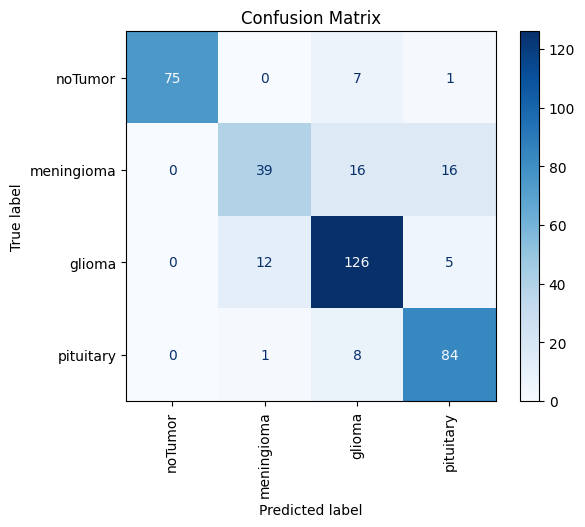

In [47]:
import torch
import cv2
import numpy as np
from torchvision import transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

checkpoint_path = os.path.join(configs['rs_dir'], "UnetMultiTask4Cls_Seg.pt")

state = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(state["net"]) 
model.to(device)
model.eval() 

# Prepare results
y_true = []
y_pred = []
total_iou = 0.0
segmented_mask = []
for i in range(len(testImagePaths)):
    img_path = testImagePaths[i] 
    

    img = cv2.imread(os.path.join(configs['image_folder'], img_path))[:,:,::-1]
    mask = np.load(os.path.join(configs['mask_folder'], img_path.replace(".png", ".npy")))
    augmented = val_tf(image=img, mask=mask)
    img_tensor = augmented['image'].unsqueeze(0).to(device) 
    mask_tensor = augmented['mask'].unsqueeze(0).to(device) 

    reverse_class = {v: k for k, v in cls_class_names.items()}
    label = img_path.split(".")[0].split("_")[1]
    true_label = reverse_class[label]

    
    with torch.no_grad():
        seg_out, cls_out = model(img_tensor)

        probs = torch.softmax(cls_out, dim=1)
        pred_class = probs.argmax(dim=1).item()

        total_iou += iou_score(seg_out, mask_tensor) 
    y_true.append(true_label)
    y_pred.append(pred_class)

    seg_pred = torch.sigmoid(seg_out)        # convert logits → probability
    seg_pred = (seg_pred > 0.5).float()      # threshold
    seg_pred = seg_pred.squeeze(0).squeeze(0).cpu().numpy()
    segmented_mask.append(seg_pred)
   

# Accuracy
total_correct = sum(1 for t, p in zip(y_true, y_pred) if t == p)
print(f"total_acc: {total_correct/len(y_true):.02f} ({total_correct}/{len(y_true)})")
print(f"average iou: {total_iou/len(y_true):.02f}")
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Only use labels that appear in test set
unique_labels = sorted(list(set(y_true + y_pred)))
display_labels = [cls_class_names[i] for i in unique_labels]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

<h1>6.2 Visualizing testing images</h1>

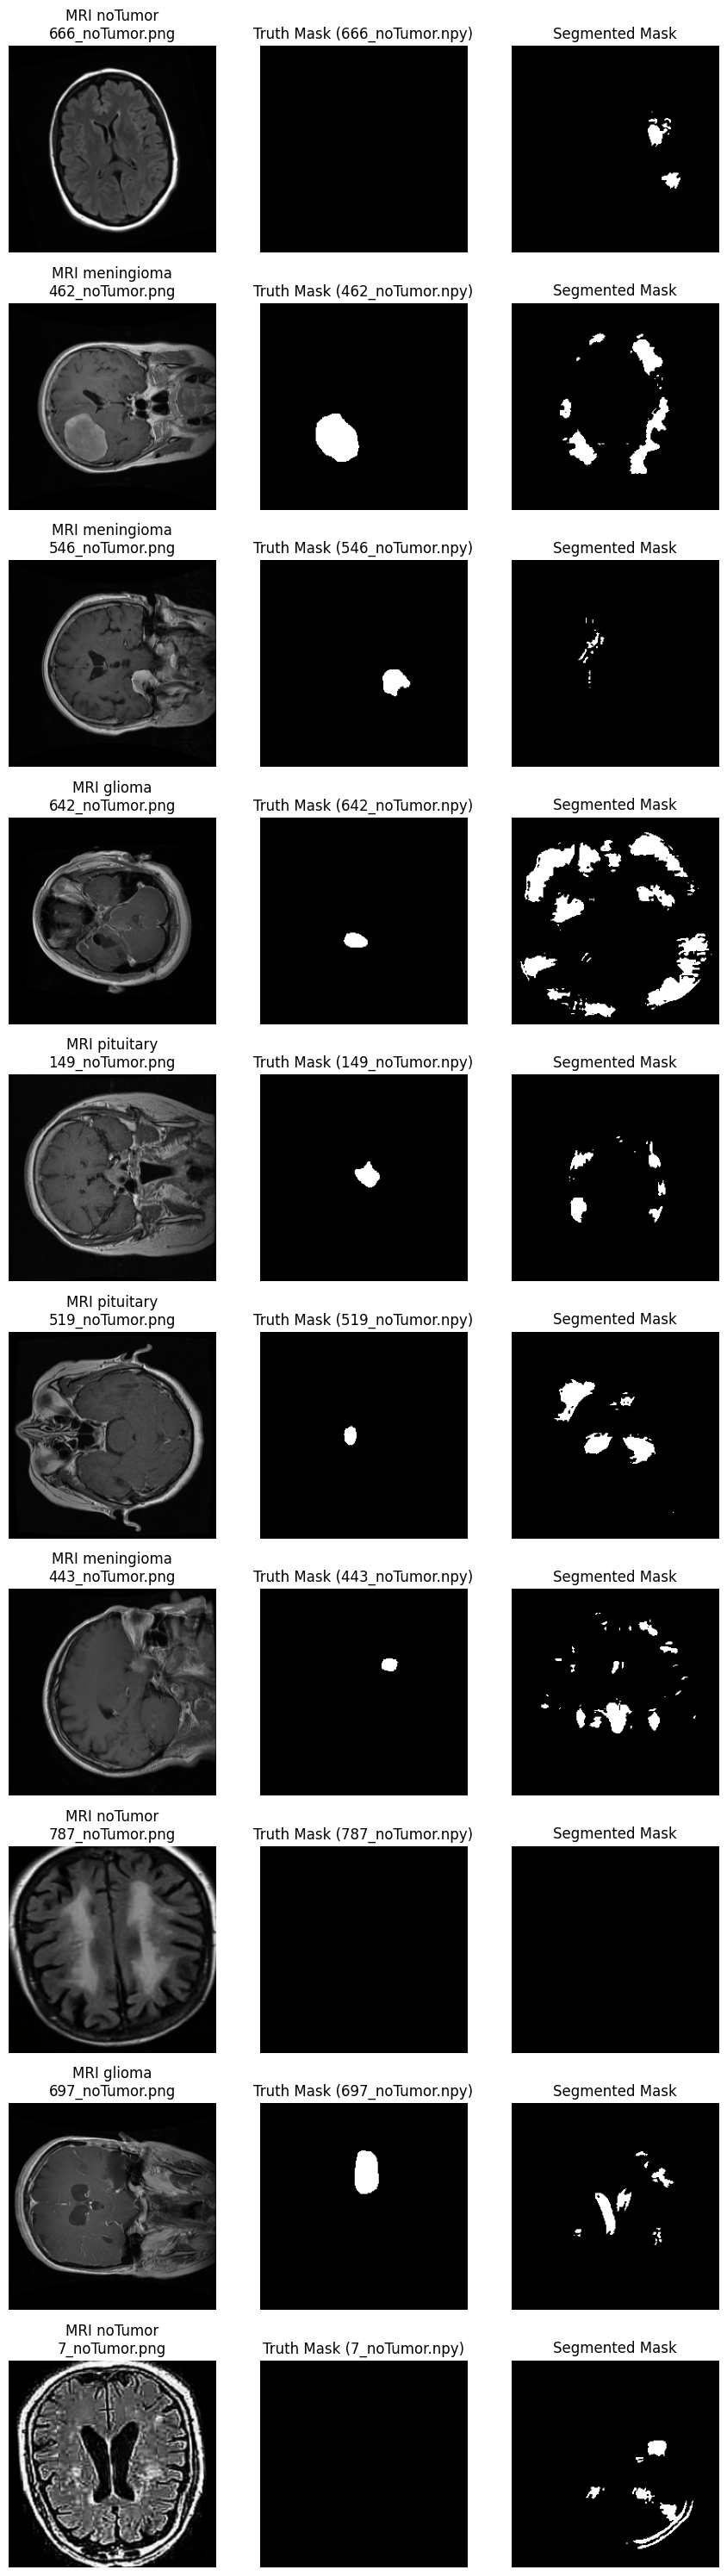

In [48]:
n = 10
plt.figure(figsize=(9, 3*n))

for i in range(n):
    
    # Image
    plt.subplot(n,3,3*i+1)
    plt.title(f"MRI {cls_class_names[labels[i].item()]}\n{testImagePaths[i]}")
    showImg = denormalize(images_to_show[i]).permute(1,2,0).numpy()
    plt.imshow(showImg)
    plt.axis('off')

    # Ground Truth Mask
    plt.subplot(n,3,3*i+2)
    plt.title(f"Truth Mask ({testImagePaths[i].replace('.png','.npy')})")
    showMask = masks_to_show[i].permute(1,2,0).numpy()
    plt.imshow(showMask, cmap='gray')
    plt.axis('off')

    # Predicted Mask
    plt.subplot(n,3,3*i+3)
    plt.title("Segmented Mask")
    
    seg_pred = segmented_mask[i]
    plt.imshow(seg_pred, cmap="gray")

    plt.axis('off')

plt.tight_layout()
plt.show()

<h1 style="text-align:center">---------------------------- End! ----------------------------</h1>